# Bayesian Neural Network Regression
Using Housing_Prices.csv dataset

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchbnn as bnn
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error, explained_variance_score
import seaborn as sns

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


In [3]:
# Load dataset
df = pd.read_csv("Housing_Prices.csv")

df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7229300521,20141013T000000,231300.0,2,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [5]:
# There is some irrelevent colums that we do not need int his case, I am going to drop here.
df = df.drop(["id", "date","zipcode","lat", "long","sqft_lot", "sqft_living","sqft_above", "yr_renovated", "sqft_lot15", "sqft_living15", "waterfront"], axis=1)

In [5]:
# encoding all variables in the dataset
from sklearn.preprocessing import LabelEncoder

# Get the list of all object columns
object_variables = df.select_dtypes(include=['object']).columns.tolist()

# Find all the boolean columns
bool_variables = [col for col in object_variables if df[col].nunique() == 2]

# Find all the categorical columns with more than 2 unique values
cat_variables = [col for col in object_variables if df[col].nunique() > 2]

encoder = LabelEncoder()
df[bool_variables] = df[bool_variables].apply(encoder.fit_transform)

# get dummies for categorical variables
df = pd.get_dummies(df, columns=cat_variables, drop_first=True)

In [6]:
# Check for nans
df.isnull().sum()

id                      0
price                   0
bedrooms                0
bathrooms               0
sqft_living             0
                       ..
date_20150513T000000    0
date_20150514T000000    0
date_20150515T000000    0
date_20150524T000000    0
date_20150527T000000    0
Length: 391, dtype: int64

In [7]:
# Split features and target
X = df.drop(columns=['price']).values
y = df['price'].values.reshape(-1, 1)

# Normalize features 
feature_scaler = StandardScaler()
X = feature_scaler.fit_transform(X)

# Normalize target variable
target_scaler = StandardScaler()
y = target_scaler.fit_transform(y)


# First, split the data into train and remaining (validation + test)
X_train, X_remaining, y_train, y_remaining = train_test_split(X, y, test_size=0.3, random_state=42)

# Second, split the remaining data into validation and test sets (e.g., 50% validation, 50% test)
X_val, X_test, y_val, y_test = train_test_split(X_remaining, y_remaining, test_size=0.5, random_state=42)


# Convert to PyTorch tensors
X_train, X_test, X_val = torch.tensor(X_train, dtype=torch.float32), torch.tensor(X_test, dtype=torch.float32), torch.tensor(X_val, dtype=torch.float32)
y_train, y_test, y_val = torch.tensor(y_train, dtype=torch.float32), torch.tensor(y_test, dtype=torch.float32), torch.tensor(y_val, dtype=torch.float32) 

# create PyTorch dataloaders, YOU CAN ADJUST THE BATCH SIZES IF YOU WISH
# basic rule: bigger batch size => faster training, but more memory needed
# only shuffle the training dataset, NEVER SHUFFLE TEST/VAL
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=64, shuffle=False)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=64, shuffle=False)

In [8]:
# all common hyperparameters we can finetune in the future

# sigma = standard deviation of the noise term (this is often optimized)
# if model is too confident and OVERFITS at the same time, INCREASE sigma
# if predictions are too noisy, too much variation or uncertain  => DECREASE sigma
# COMMON VALUES 0.1 - 0.5

# lambda_kl = amount of KL in the loss function => regularization parameter to avoid OVERFITTING
# if model overfits => increase, if model underfits => decrease
# COMMON VALUES 0.0+ - 0.2

# mu = mean of distribution (you can usually use the defaul 0 in classification)
# if model overfits => decrease mu
# if model underfits => increase mu
# mu = 0 => in the middle of standard distribution (range -3 to +3) => this needs be checked!
# COMMON VALUES: usually 0 in classification

# mc_samples_eval = monte carlo sample size used to approximate distributions in weights
# more samples used => more accurate uncertainty estimation (but heavier to compute)
# if uncertainty is not optimal, try increasing mc_sample -size a little bit
# if model training is too heavy or underfits, you can decrease the sample size
# COMMON VALUES: 25 - 200

mu = 0
sigma = 0.4
lambda_kl = 0.1
mc_samples_eval = 50

# remember to adjust the BNN network structure in the below cell if needed
# amount of layers, layer sizes, amount of dropout regularization etc.

# learning rate is same as in ANN => controls the aggressiveness of optimization
# too large value => model overshoots optimization attempts
# too small value => model learns too slowly
# COMMON VALUES similar to ANN learning rates, small values (0.03 or less), usually 0.1 or less
bnn_learning_rate = 0.001

# weight_decay = regularization applied to model weights (probability distributions)
# penalizes large weights IN ORDER to prevent OVERFITTING
# if model overfits => you can try increasing weight decay, if underfits => try decreasing
# COMMON VALUES are usually quite small, 0.0001 to 0.0005
bnn_weight_decay = 0.0001

In [9]:
# Bayesian Neural Network -model (BNN) with deeper layers and Monte-Carlo dropout
class BayesianNN(nn.Module):
    def __init__(self, input_dim, output_dim, mu=0, sigma=0.5):
        super().__init__()
        # DEFINE ALL LAYERS THAT WILL BE COMBINED INTO ONE MODEL IN forward()
        # NOTE: Torch requires as to "chain" connected layer => out_features and in_features have to match in connected layers
        # for example "in_features=96, out_features=48" means that previous layers to have out_features of 96
        # and the next layer has to have in features of 48
        self.fc1 = bnn.BayesLinear(prior_mu=mu, prior_sigma=sigma, in_features=input_dim, out_features=128)
        self.fc2 = bnn.BayesLinear(prior_mu=mu, prior_sigma=sigma, in_features=128, out_features=64)
        self.fc3 = bnn.BayesLinear(prior_mu=mu, prior_sigma=sigma, in_features=64, out_features=32)
        self.fc4 = bnn.BayesLinear(prior_mu=mu, prior_sigma=sigma, in_features=32, out_features=16)
        self.fc5 = bnn.BayesLinear(prior_mu=mu, prior_sigma=sigma, in_features=16, out_features=output_dim)
        self.relu = nn.ReLU()

        # adjust dropout rate to increase regularization
        self.dropout = nn.Dropout(0.3)  

        # THE BATCH NORMALIZATION SIZES HAVE THE MATCH THE OUTPUT OF THE CORRESPONDING LAYER
        self.batch_norm1 = nn.BatchNorm1d(128)
        self.batch_norm2 = nn.BatchNorm1d(64)
        self.batch_norm3 = nn.BatchNorm1d(32)
        self.batch_norm4 = nn.BatchNorm1d(16)
    
    # "forward pass", if mc_dropout = True => adds a dropout layer between the BayesLinear -layers
    def forward(self, x, mc_dropout=False):
        # NOTE: batch normalization helps in stabilizing the training process
        x = self.batch_norm1(self.relu(self.fc1(x))) 
        x = self.dropout(x) if mc_dropout else x
        x = self.batch_norm2(self.relu(self.fc2(x)))
        x = self.dropout(x) if mc_dropout else x
        x = self.batch_norm3(self.relu(self.fc3(x)))
        x = self.dropout(x) if mc_dropout else x
        x = self.batch_norm4(self.relu(self.fc4(x)))
        x = self.dropout(x) if mc_dropout else x
        return self.fc5(x)

In [10]:
# model, loss, optimizer
# NOTE! Regression, OUTPUT DIMENSION IS 1 VARIABLE!
model = BayesianNN(input_dim=X.shape[1], 
                   output_dim=1,
                   sigma=sigma,
                   mu=mu
                   )

# Loss function for REGRESSION
criterion = nn.MSELoss() 

# Bayesian KL Divergence Loss (efficient regularization for BNN)
bkl_loss = bnn.BKLLoss(reduction='mean')  

# AdamW is common in BNN
optimizer = optim.AdamW(model.parameters(), lr=bnn_learning_rate, weight_decay=bnn_weight_decay)

In [11]:
# Evaluate function with uncertainty estimation
def evaluate(model, loader, mc_samples=50):
    model.eval() # Set model to evaluation mode
    total_loss = 0
    uncertainties = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            outputs_list = [model(X_batch, mc_dropout=True) for _ in range(mc_samples)]
            outputs_stack = torch.stack(outputs_list)  # Shape: (mc_samples, batch_size, num_classes)
            outputs_mean = outputs_stack.mean(dim=0)  # Average prediction
            outputs_std = outputs_stack.std(dim=0)  # Standard deviation (uncertainty)

            loss = criterion(outputs_mean, y_batch)
            total_loss += loss.item()


            uncertainties.extend(outputs_std.mean(dim=1).cpu().numpy())  # Store uncertainty per sample

    r2 = r2_score(y_batch.cpu().numpy(), outputs_mean.cpu().numpy())  # Use R^2 score for regression tasks
    avg_loss = total_loss / len(loader) # Average loss across all batches
    avg_uncertainty = np.mean(uncertainties)  # Average uncertainty across all samples

    print(f"Val. confidence score: {r2:.4f}, Val. loss: {avg_loss:.4f}, Avg. Uncertainty: {avg_uncertainty:.4f}")

    return r2, avg_loss, avg_uncertainty, uncertainties  # Return per-sample uncertainty if needed

# Training loop with BKLLoss
def train(model, loader, epochs=50):
    model.train()
    history = {}
    history['train_loss'] = []
    history['val_loss'] = []
    history['r2'] = []
    history['avg_uncertainty'] = []
    for epoch in range(epochs):
        total_loss = 0
        for X_batch, y_batch in loader:
            optimizer.zero_grad()
            outputs = model(X_batch, mc_dropout=True)
            target_loss = criterion(outputs, y_batch) # Compute target loss
            kl_loss = bkl_loss(model)  # Compute BKL loss
            loss = target_loss + lambda_kl * kl_loss  # Combine losses
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs}, Training Loss: {total_loss/len(loader):.4f}")

        r2, val_loss, avg_uncertainty, _ = evaluate(model, val_loader)
        history['train_loss'].append(total_loss / len(loader))
        history['val_loss'].append(val_loss)
        history['r2'].append(r2)
        history['avg_uncertainty'].append(avg_uncertainty)

        # set model to training mode for next epoch
        model.train()
        
    return history

In [12]:
# train the model (fit), epochs are usually 1000-5000 with BNN classification
# here we can see how quickly the amount of data slows down the training process
history = train(model, train_loader, epochs=3500)

Epoch 1/3500, Training Loss: 4.2774
Val. confidence score: -0.0227, Val. loss: 1.0121, Avg. Uncertainty: 0.9095
Epoch 2/3500, Training Loss: 3.0500
Val. confidence score: -0.0667, Val. loss: 1.0089, Avg. Uncertainty: 0.7565
Epoch 3/3500, Training Loss: 2.3852
Val. confidence score: -0.0649, Val. loss: 0.9939, Avg. Uncertainty: 0.6386
Epoch 4/3500, Training Loss: 2.0311
Val. confidence score: 0.0328, Val. loss: 0.9921, Avg. Uncertainty: 0.5362
Epoch 5/3500, Training Loss: 1.6358
Val. confidence score: -0.0554, Val. loss: 0.9895, Avg. Uncertainty: 0.4671
Epoch 6/3500, Training Loss: 1.5181
Val. confidence score: -0.0290, Val. loss: 0.9923, Avg. Uncertainty: 0.4234
Epoch 7/3500, Training Loss: 1.3644
Val. confidence score: 0.0065, Val. loss: 0.9876, Avg. Uncertainty: 0.3600
Epoch 8/3500, Training Loss: 1.2720
Val. confidence score: -0.0048, Val. loss: 0.9881, Avg. Uncertainty: 0.3237
Epoch 9/3500, Training Loss: 1.1901
Val. confidence score: -0.0111, Val. loss: 0.9865, Avg. Uncertainty: 0

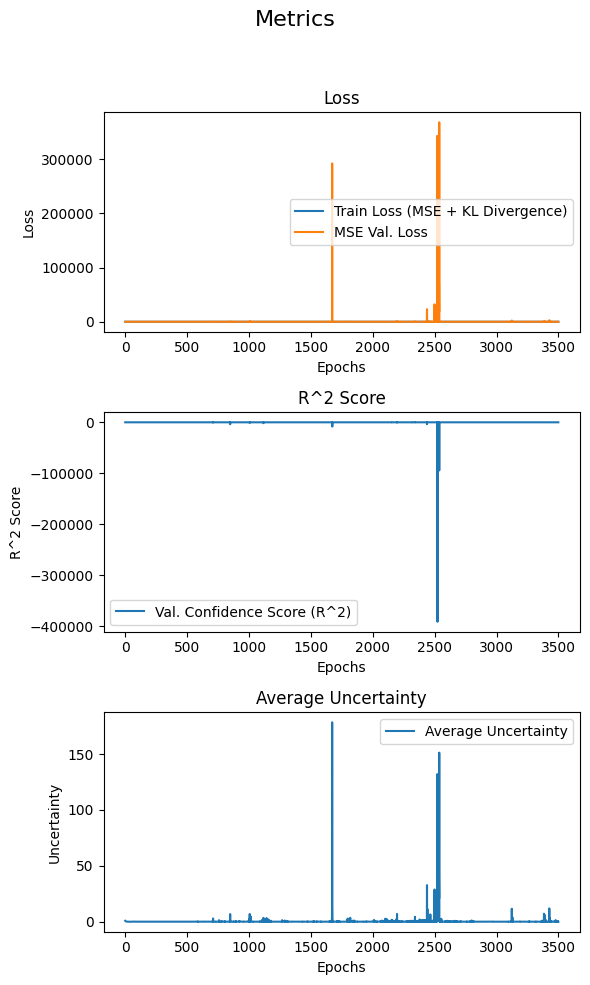

In [13]:
# Plot training history
fig, axes = plt.subplots(3, 1, figsize=(6, 10))
plt.suptitle('Metrics', fontsize=16)

# Losses
axes[0].plot(history['train_loss'], label='Train Loss (MSE + KL Divergence)')
axes[0].plot(history['val_loss'], label='MSE Val. Loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Confidence Score
axes[1].plot(history['r2'], label='Val. Confidence Score (R^2)')
axes[1].set_title('R^2 Score')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('R^2 Score')
axes[1].legend()

# Uncertainty
axes[2].plot(history['avg_uncertainty'], label='Average Uncertainty')
axes[2].set_title('Average Uncertainty')
axes[2].set_xlabel('Epochs')
axes[2].set_ylabel('Uncertainty')
axes[2].legend()


plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [14]:
# Get the metrics
model.eval()
y_true = y_test.numpy()
y_pred = []
uncertainties = []

with torch.no_grad():
    for X_batch, Y_batch in test_loader:
        outputs_list = [model(X_batch, mc_dropout=True) for _ in range(1000)] # Increase the number of MC samples for better uncertainty estimation
        outputs_stack = torch.stack(outputs_list)  # Shape: (mc_samples, batch_size, num_classes)
        outputs_mean = outputs_stack.mean(dim=0)  # Average prediction
        outputs_std = outputs_stack.std(dim=0)
        y_pred.extend(outputs_mean.cpu().numpy())
        uncertainties.extend(outputs_std.mean(dim=1).cpu().numpy())

y_pred = np.array(y_pred).reshape(-1, 1)

# Unscale the predictions and true values
y_pred = target_scaler.inverse_transform(y_pred)
y_true = target_scaler.inverse_transform(y_true)

In [15]:
# MAE
mae = mean_absolute_error(y_true, y_pred)
print(f"Mean Absolute Error (MAE): {mae:.4f}")

# RMSE
rmse = root_mean_squared_error(y_true, y_pred)
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

# R^2 Score
r2 = r2_score(y_true, y_pred)
print(f"R^2 Score: {r2:.4f}")

# Average Uncertainty
avg_uncertainty = np.mean(uncertainties)
print(f"Average Uncertainty: {avg_uncertainty:.4f}")

# Explained Variance Score
evs = explained_variance_score(y_true, y_pred)
print(f"Explained Variance Score: {evs:.4f}")

# this model doesn't work that well, but this dataset
# is very noise and similar results were achieved with Classic ML and ANN in previous courses

Mean Absolute Error (MAE): 95268.5000
Root Mean Squared Error (RMSE): 173808.1406
R^2 Score: 0.8069
Average Uncertainty: 0.1343
Explained Variance Score: 0.8089


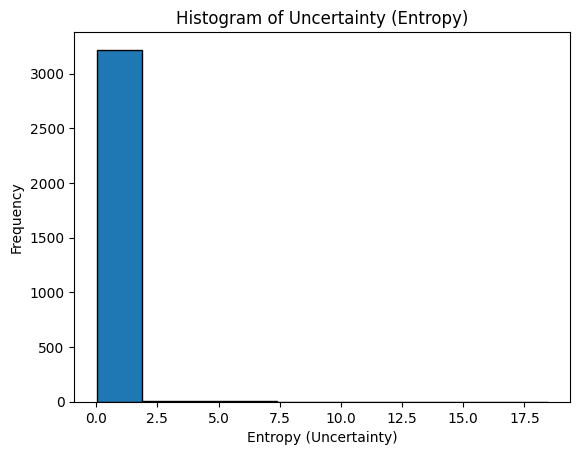

In [16]:
# plot uncertainty histogram
plt.hist(uncertainties, bins=10, edgecolor='k')
plt.xlabel('Entropy (Uncertainty)')
plt.ylabel('Frequency')
plt.title('Histogram of Uncertainty (Entropy)')
plt.show()

# in optimal case, entropy is stacked on the left side
# with only a small number of uncertainty on the high end

# this particular example is a very bad result, most uncertainty
# is in the high end

# the multi-category version is not usable by default in regression (because we don't have target categories)
# but it might be possible to use binning to inspect in which price ranges the uncertainties happen the most

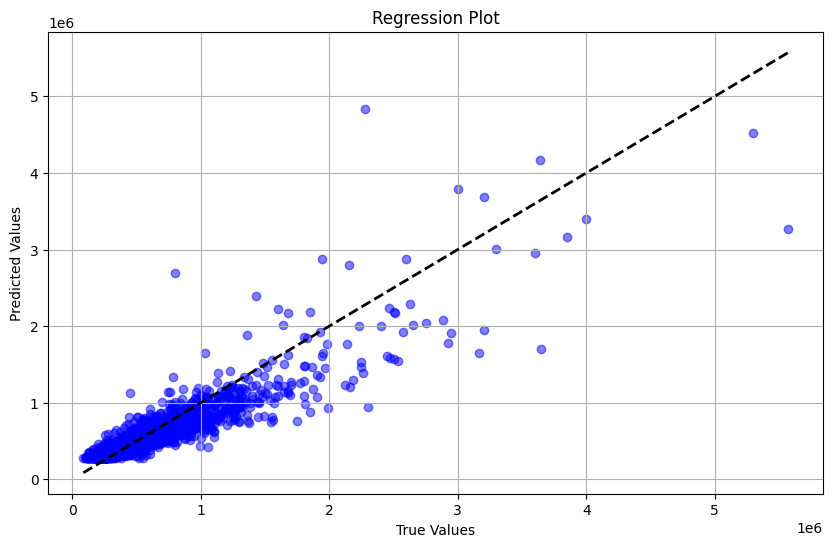

In [17]:
# Regression plot
plt.figure(figsize=(10, 6))
plt.scatter(y_true, y_pred, alpha=0.5, color='blue')
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'k--', lw=2)
plt.title('Regression Plot')
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.grid()

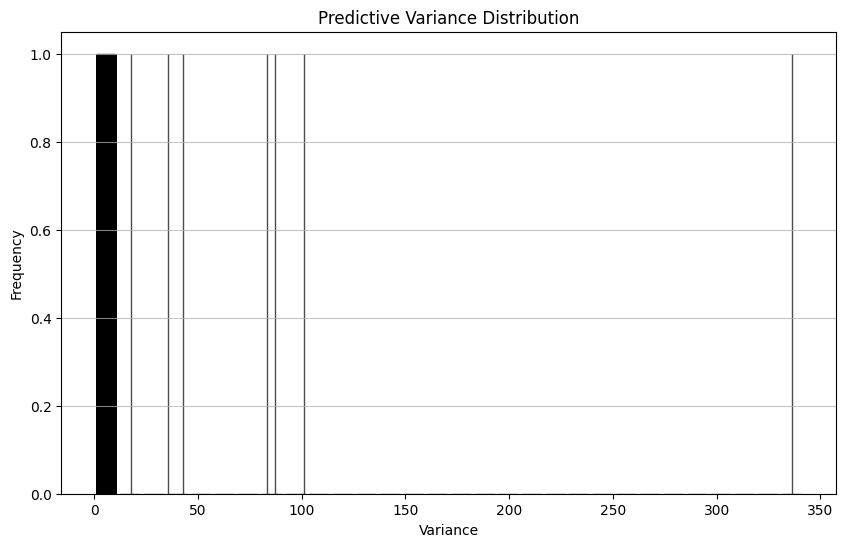

In [18]:
# original code from ChatGPT and modified for this project (data and neural network structure)
# Assuming `model` performs MC Dropout and `test_loader` provides data
variances = []  # List to store predictive variance (or standard deviation)

model.eval()
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        # Perform multiple forward passes for MC Dropout
        outputs_list = [model(X_batch, mc_dropout=True) for _ in range(10)]
        outputs_stack = torch.stack(outputs_list)
        
        # Calculate variance across the predictions
        variance = outputs_stack.var(dim=0).cpu().numpy()  # Variance of each prediction
        variances.extend(variance)

# Plot predictive variance (uncertainty)
plt.figure(figsize=(10, 6))
plt.hist(variances, bins=30, alpha=0.7, edgecolor='black')
plt.title('Predictive Variance Distribution')
plt.xlabel('Variance')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

# most values should stack close to 0.0... otherwise it usually means noise in the dataset or underfitting
# or difficult data points / overlap

# so improve dataset or model structure / hyperparameters

In [19]:
df.iloc[542]

id                      1310900260
price                     318888.0
bedrooms                         4
bathrooms                     1.75
sqft_living                   2320
                           ...    
date_20150513T000000         False
date_20150514T000000         False
date_20150515T000000         False
date_20150524T000000         False
date_20150527T000000         False
Name: 542, Length: 391, dtype: object

In [ ]:
# ORIGINAL CODE FROM CHATGPT AND MODIFIER FOR THE TESTER ROW STRUCTURE FROM EARLIER COURSES

# Define the function for prediction with uncertainty
def predict_with_uncertainty(model, data, feature_scaler, target_scaler, mc_samples=100):
    """
    Predict the price and uncertainty (using MC Dropout) for a new row of data.

    :param model: The trained Bayesian Neural Network model
    :param data: Processed input data for prediction
    :param feature_scaler: Scaler for the input features (used during training)
    :param target_scaler: Scaler for the target variable (price) used during training
    :param mc_samples: Number of Monte Carlo samples to estimate uncertainty
    :return: predicted_price, uncertainty (standard deviation)
    """
    model.eval()  # Set the model to evaluation mode
    predictions = []

    with torch.no_grad():
        for _ in range(mc_samples):
            # Apply MC dropout during inference
            prediction = model(data, mc_dropout=True)  # Get predictions using MC dropout
            predictions.append(prediction.cpu().numpy())

    predictions = np.array(predictions).flatten()  # Flatten predictions to 1D array

    # Compute the mean (predicted value) and the uncertainty (standard deviation)
    predicted_price = predictions.mean()
    uncertainty = predictions.std()

    # Inverse transform the predicted price and uncertainty to original scale
    predicted_price = target_scaler.inverse_transform([[predicted_price]])[0][0]  # Rescale predicted price

    # Uncertainty might need to be scaled back to original scale (if it was scaled during training)
    # uncertainty = uncertainty * target_scaler.scale_[0]  # Scale the uncertainty back to original price scale

    return predicted_price, uncertainty


# Example new row for prediction (using your dataset)
tester_row = {
    "area": 3620,
    "bedrooms": 2,	
    "bathrooms": 1,
    "stories": 1,	
    "mainroad": 1, 
    "guestroom": 0,
    "basement": 0,
    "hotwaterheating": 0,
    "airconditioning": 0,
    "parking": 0,
    "prefarea": 0,
    "furnishingstatus_semi-furnished": 0,	
    "furnishingstatus_unfurnished": 1
}

# Convert the new data to pandas DataFrame
tester_row = pd.DataFrame([tester_row])

# Normalize the input features using feature_scaler (if you scaled them during training)
processed_data = feature_scaler.transform(tester_row.values)

# Convert the scaled data into a tensor
processed_data_tensor = torch.tensor(processed_data, dtype=torch.float32)

# Call the prediction function to get the price and uncertainty
predicted_price, uncertainty = predict_with_uncertainty(model, processed_data_tensor, feature_scaler, target_scaler)

# Output the result
print("\nEstimated price for this house:")
print(f"$ {round(predicted_price, 2)}")
print(f"Uncertainty (Standard Deviation): {round(uncertainty, 2)}")
print("----------------")